# Empirical SPN clustering figures

This notebook reads the plotting tables generated by Notebooks 02 and 03 and produces:

- `Fig2_example_empirical_spn_profiles.png`
- `FigS3_steinmetz_profiles_and_correlations.png`
- `FigS4_ibl_profiles_and_correlations.png`

It does not rerun preprocessing or clustering. 

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from spn_figures.config import DERIVED, FIGURES
from spn_figures.io import read_csv, save_figure
from spn_figures.plotting import (
    empirical_profile_unit_counts,
    plot_empirical_example_profiles_exact,
    plot_empirical_profile_correlation_grid_exact,
)

stein_profiles = read_csv(DERIVED / "steinmetz" / "unit_profiles.csv.gz")
stein_corr = read_csv(DERIVED / "steinmetz" / "correlations.csv")
ibl_profiles = read_csv(DERIVED / "ibl" / "unit_profiles.csv.gz")
ibl_corr = read_csv(DERIVED / "ibl" / "correlations.csv")

profiles = pd.concat([stein_profiles, ibl_profiles], ignore_index=True)
correlations = pd.concat([stein_corr, ibl_corr], ignore_index=True)

In [3]:
DISPLAY_NAMES = {
    "Hench_2017-06-18": "SteinmetzLab | Hench | 2017-06-18",
    "Lederberg_2017-12-11": "SteinmetzLab | Lederberg | 2017-12-11",
    "Radnitz_2017-01-12": "SteinmetzLab | Radnitz | 2017-01-12",
    "Richards_2017-11-01": "SteinmetzLab | Richards | 2017-11-01",
    "churchlandlab | CSHL049 | 2020-01-08": "ChurchlandLab | CSHL049 | 2020-01-08",
    "zadorlab | CSH_ZAD_026 | 2020-08-17": "ZadorLab | CSH_ZAD_026 | 2020-08-17",
    "danlab | DY_014 | 2020-07-18": "DanLab | DY_014 | 2020-07-18",
    "hoferlab | SWC_061 | 2020-11-23": "HoferLab | SWC_061 | 2020-11-23",
    "mrsicflogellab | SWC_038 | 2020-07-31": "MrsicflogelLab | SWC_038 | 2020-07-31",
    "mrsicflogellab | SWC_038 | 2020-08-01": "MrsicflogelLab | SWC_038 | 2020-08-01",
    "cortexlab | KS086 | 2022-03-16": "CortexLab | KS086 | 2022-03-16",
}

FIG2_SESSIONS = [
    "Hench_2017-06-18",
    "churchlandlab | CSHL049 | 2020-01-08",
    "zadorlab | CSH_ZAD_026 | 2020-08-17",
]
STEINMETZ_SESSIONS = [
    "Hench_2017-06-18",
    "Lederberg_2017-12-11",
    "Radnitz_2017-01-12",
    "Richards_2017-11-01",
]
IBL_SESSIONS = [
    "churchlandlab | CSHL049 | 2020-01-08",
    "zadorlab | CSH_ZAD_026 | 2020-08-17",
    "danlab | DY_014 | 2020-07-18",
    "hoferlab | SWC_061 | 2020-11-23",
    "mrsicflogellab | SWC_038 | 2020-07-31",
    "mrsicflogellab | SWC_038 | 2020-08-01",
    "cortexlab | KS086 | 2022-03-16",
]

empirical_profile_unit_counts(profiles)

spn_name,dSPN_left,iSPN_left,dSPN_right,iSPN_right
session,,,,
Hench_2017-06-18,3,19,24,4
Lederberg_2017-12-11,3,13,9,4
Radnitz_2017-01-12,7,15,25,3
Richards_2017-11-01,5,7,10,13
churchlandlab | CSHL049 | 2020-01-08,9,8,4,3
cortexlab | KS086 | 2022-03-16,5,4,3,11
danlab | DY_014 | 2020-07-18,4,7,7,11
hoferlab | SWC_061 | 2020-11-23,9,8,3,4
mrsicflogellab | SWC_038 | 2020-07-31,3,5,3,5


### Fig. 2: three example empirical sessions

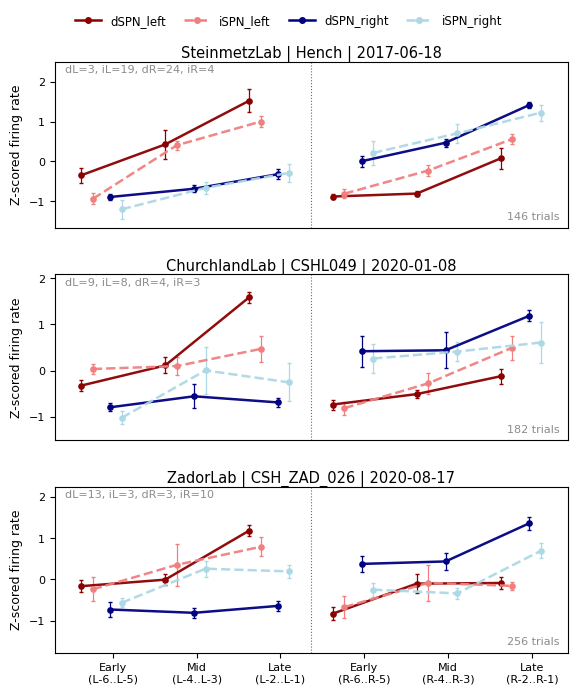

In [4]:
fig = plot_empirical_example_profiles_exact(
    profiles,
    correlations,
    FIG2_SESSIONS,
    DISPLAY_NAMES,
)
save_figure(fig, FIGURES / "main" / "Fig2_example_empirical_spn_profiles")
plt.show()

### Fig. S3: Steinmetz sessions

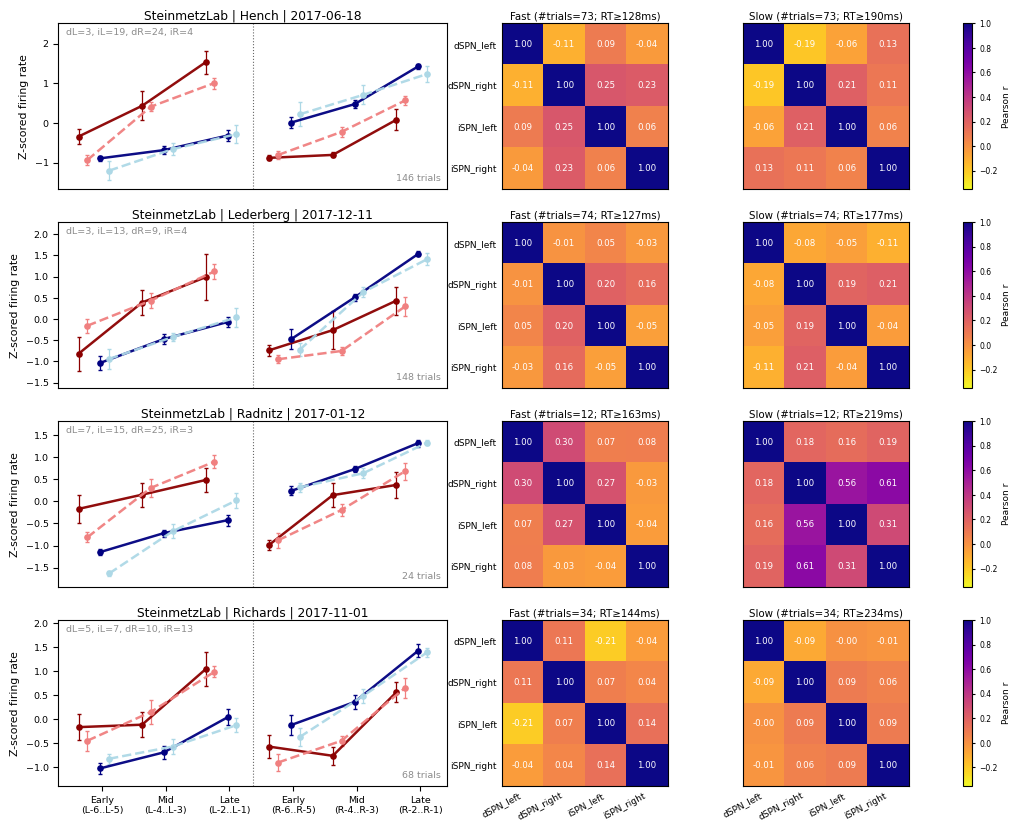

In [5]:
fig = plot_empirical_profile_correlation_grid_exact(
    stein_profiles,
    stein_corr,
    STEINMETZ_SESSIONS,
    DISPLAY_NAMES,
    row_height=2.05,
)
save_figure(fig, FIGURES / "supporting" / "FigS3_steinmetz_profiles_and_correlations")
plt.show()

### Fig. S4: IBL sessions

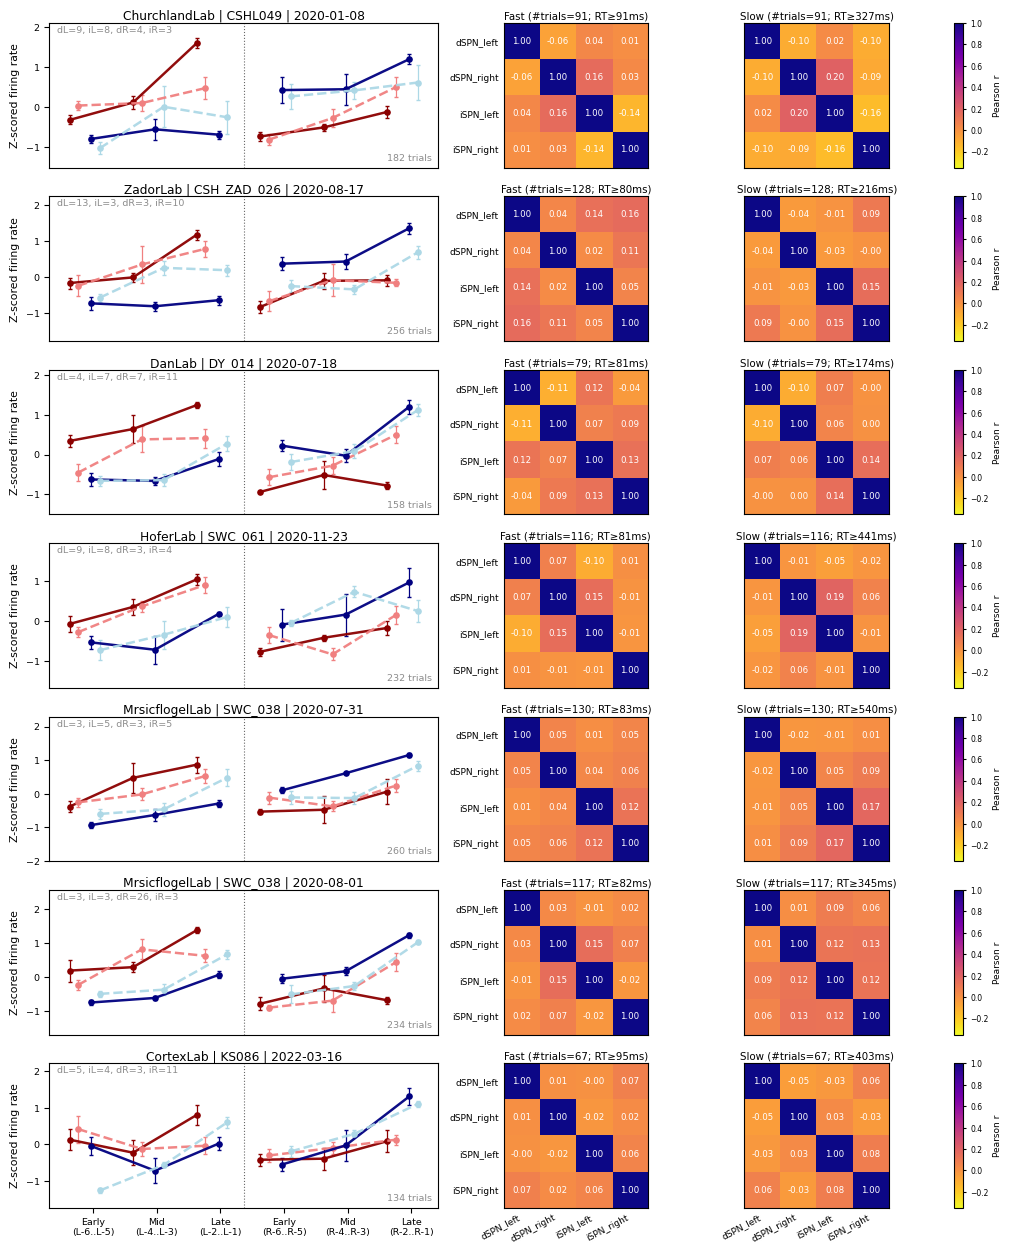

In [6]:
fig = plot_empirical_profile_correlation_grid_exact(
    ibl_profiles,
    ibl_corr,
    IBL_SESSIONS,
    DISPLAY_NAMES,
    row_height=1.82,
)
save_figure(fig, FIGURES / "supporting" / "FigS4_ibl_profiles_and_correlations")
plt.show()